# Tree surgery and subtrees

Here we cover the three main structural edits you will do on morphologies:
**reducing**, **rerooting**, and **extracting subtrees**. These are the same
ops the GUI exposes for interactive curation — see {doc}`gui` after this.

Reduction is also introduced in {doc}`tree_basics`; this notebook focuses on
when to use it in a surgery workflow, then goes deep on reroot + subtree tools.

```{important}
`get_reduced_tree(inplace=False)` and `get_rerooted_tree(..., inplace=False)`
return a **graph-tool `Graph`**, not a `Tree`. Prefer `inplace=True` unless you
know you want the raw graph.

`get_subtree()` always edits the tree **in place** — copy first if you need the
full arbor afterwards.
```


In [1]:
import matplotlib.pyplot as plt
import neurosetta as nr

%matplotlib inline

tree = nr.load_example_data(nr.example_ids[0])
tree.summary()


ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,2010,99,111,404.2,micron,False,False


## Reducing trees

A full reconstruction is mostly **transitive** (degree-2) nodes that sample
section curvature. A **reduced** tree keeps only the root, branch points, and
leaves (NeuRosetta's *core* nodes), collapsing chains into single edges while
preserving cable length on `Path_length`.

| Before / after | What changes |
|----------------|--------------|
| Node count | Typically drops ~10× |
| Topology | Branch / leaf / root set unchanged |
| Cable | `get_total_cable_length()` stays the same if `Path_length` existed |
| Metadata | `isReduced` becomes `True` |

If you only need a refresher on `Path_length` vs `Euclidean_length`, see the
**Reduced Trees** section in {doc}`tree_basics`. Here we do the edit and
compare morphology size:


In [2]:
print(f"before: {tree.count_nodes()} nodes, reduced={tree.is_reduced()}")
print(f"cable:  {tree.get_total_cable_length():.2f} {tree.get_units()}")

tree.get_reduced_tree(inplace=True)

print(f"after:  {tree.count_nodes()} nodes, reduced={tree.is_reduced()}")
print(f"cable:  {tree.get_total_cable_length():.2f} {tree.get_units()}")
tree.summary()


before: 2010 nodes, reduced=False
cable:  404.24 micron
after:  211 nodes, reduced=True
cable:  404.24 micron


ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,211,99,111,404.2,micron,True,False


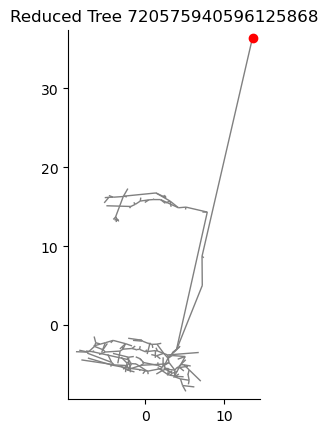

In [3]:
ax = tree.show_2d()
ax.set_title(f"Reduced Tree {tree.ID}")
plt.show()


You can also call the functional form `nr.reduce_tree(tree, inplace=True)` —
same thing. With `inplace=False` you get a bare `Graph` back and the original
`Tree` is untouched:

```python
g = tree.get_reduced_tree(inplace=False)  # graph_tool.Graph
```

For batch work, `Forest.reduce_tree(inplace=True)` reduces every tree in the
forest.


## Rerooting

NeuRosetta trees are **directed** away from a single root. That root is often
the soma, but incomplete or SWC-exported morphologies can be rooted at an
arbitrary tip. Rerooting flips edge directions so a chosen node becomes the
new root.

Typical reasons to reroot:

- Put the soma (or a known proximal point) at the root before metrics
- Align trees for comparison / dendrogram layout
- Prepare a subtree extraction from a branch of interest

Pick a leaf, remember its coordinate, reroot, and check that the new root sits
at that same point:


In [12]:
tree = nr.load_example_data(nr.example_ids[0])

leaf = int(tree.get_leaf_indices()[0])
leaf_xyz = tree.get_node_coordinates()[leaf]
print(f"chosen leaf index: {leaf}")
print(f"leaf coordinate:   {leaf_xyz}")
print(f"root before:       {tree.get_root_index()} @ {tree.get_root_coordinate()}")

tree.get_rerooted_tree(leaf, inplace=True)

print(f"root after:        {tree.get_root_index()} @ {tree.get_root_coordinate()}")


chosen leaf index: 232
leaf coordinate:   [714.315   265.52925 217.119  ]
root before:       0 @ [723.45567568 274.77648649 242.55340541]
root after:        0 @ [714.315   265.52925 217.119  ]


Two things to notice:

1. **Coordinates match** — the morphology did not move in space; only edge
   orientation and the root identity changed.
2. **The root index is usually `0` after reroot** — the graph is rebuilt, so
   vertex indices are not stable across the call. Always re-query
   `get_root_index()` / coordinates rather than caching old indices.

Same `inplace` caveat as reduction: `inplace=False` returns a `Graph`.

The GUI's **Reroot Neuron** tool is this method behind a point picker — see
{doc}`gui`.


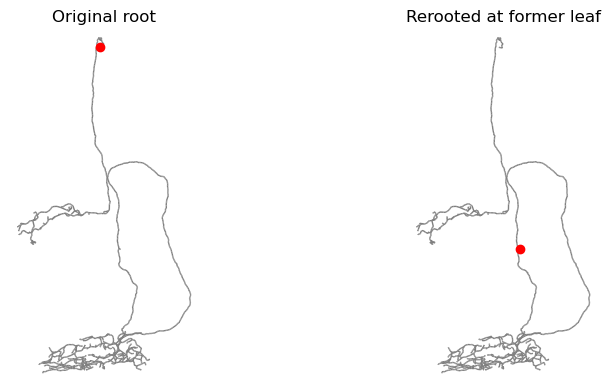

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# reload pristine tree for a before/after view
before = nr.load_example_data(nr.example_ids[0])
before.show_2d(axes=axes[0], show_root=True)
axes[0].set_title("Original root")
axes[0].set_axis_off()

tree.show_2d(axes=axes[1], show_root=True)
axes[1].set_title("Rerooted at former leaf")
axes[1].set_axis_off()
plt.tight_layout()
plt.show()


## Subtrees

A subtree is the set of nodes **downstream** of a chosen vertex (including that
vertex), following directed edges away from the global root.

You typically either:

1. **Inspect** a subtree without destroying the tree (`get_subtree_indices`,
   scores, partition asymmetry), or
2. **Extract** it permanently (`subtree_mask_from_root` → `get_subtree`).

### Inspect without extracting

`get_subtree_indices(root)` returns the node indices of the downstream arbor.
Useful for masking coordinates, colouring plots, or feeding other metrics:


In [14]:
tree = nr.load_example_data(nr.example_ids[0])

branch = int(tree.get_branch_indices()[5])
inds = tree.get_subtree_indices(branch)
print(f"subtree root (branch node): {branch}")
print(f"subtree size: {len(inds)} / {tree.count_nodes()} nodes")

# coordinates of just that arbor
xyz = tree.get_subtree_node_coordinates(branch)
print(f"subtree coords shape: {xyz.shape}")


subtree root (branch node): 372
subtree size: 107 / 2010 nodes
subtree coords shape: (107, 3)


### Subtree scores

`get_subtree_scores` ranks every **branch** node by a simple morphology score:

\[
\text{score}(v) =
\bigl(1 - \tfrac{\text{subtree cable}(v)}{\text{total cable}}\bigr)
+
\tfrac{\text{subtree leaves}(v)}{\text{total leaves}}
\]

Non-branch nodes score `0`. High scores favour relatively **compact, leaf-rich**
subtrees that are not the bulk of the arbor — a cheap heuristic for "interesting
side branches".

`get_max_subtree_node()` returns the argmax (and will compute/bind scores if
needed):


In [15]:
tree = nr.load_example_data(nr.example_ids[0])

scores = tree.get_subtree_scores(bind=False)
best = tree.get_max_subtree_node()
print(f"best node: {best}")
print(f"score:     {scores[best]:.4f}")
print(f"nonzero scores (branch points): {(scores > 0).sum()}")

best_inds = tree.get_subtree_indices(best)
print(f"best subtree size: {len(best_inds)} nodes")


best node: 363
score:     1.2109
nonzero scores (branch points): 99
best subtree size: 1115 nodes


With `bind=True` (the default), scores land on the vertex property
`subgraph_score` and the method returns `None` — same bind pattern as other
NeuRosetta metrics.


### Mask then extract

Extraction is a two-step, **in-place** process:

1. `subtree_mask_from_root(v)` — bind boolean vertex/edge masks
   (`v_subtree_mask` / `e_subtree_mask`)
2. `get_subtree()` — replace the tree's graph with the masked subgraph

If you call `get_subtree()` with no mask, it defaults to the max-score node.

```{warning}
This destroys the rest of the arbor on that `Tree` instance. Use `tree.copy()`
first if you still need the full morphology.
```


In [16]:
full = nr.load_example_data(nr.example_ids[0])
work = full.copy()

v = int(work.get_branch_indices()[5])
print(f"extracting subtree from branch {v}")
print(f"nodes before: {work.count_nodes()}")

work.subtree_mask_from_root(v)
print(f"mask bound? {work.has_property('v_subtree_mask', level='v')}")

work.get_subtree()
print(f"nodes after:  {work.count_nodes()}")
print(f"new root:     {work.get_root_index()} @ {work.get_root_coordinate()}")
work.summary()


extracting subtree from branch 372
nodes before: 2010
mask bound? True
nodes after:  107
new root:     0 @ [708.36536842 262.92442105 205.70384211]


ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,107,8,9,20.7,micron,False,False


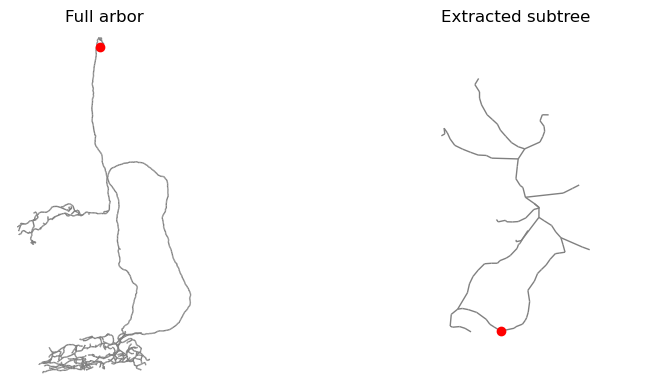

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
full.show_2d(axes=axes[0])
axes[0].set_title("Full arbor")
axes[0].set_axis_off()

work.show_2d(axes=axes[1])
axes[1].set_title("Extracted subtree")
axes[1].set_axis_off()
plt.tight_layout()
plt.show()


`get_subtree(revert_properties=True)` (default) strips non-core bound
properties after extraction so you do not keep stale arrays sized for the old
graph. Pass `revert_properties=False` only if you know the remaining properties
are still valid.

After a heavy edit, if 3D plotting looks wrong, rebuild actors with
`tree.plot3d.rebuild()` or save/reload an `.nr` file — same caveat as the GUI.


### Partition asymmetry

`get_partition_asymmetry` scores how uneven the child subtrees are at each
branch point. For a binary node with downstream leaf counts \(r\) and \(s\):

\[
PA = \frac{|r - s|}{r + s - 1}
\]

For \(k>2\) children the score is the mean over all child pairs. With
`weighted=True` (default) that value is scaled by the fraction of total cable
in the node's subtree.

Leaves and the root get `0`. This is a per-node descriptor, not a surgery
tool — bind it when you want it persisted on the graph:


In [11]:
tree = nr.load_example_data(nr.example_ids[0])
pa = tree.get_partition_asymmetry(weighted=True, bind=False)

branches = tree.get_branch_indices()
print(f"branch points: {len(branches)}")
print(f"PA > 0:        {(pa > 0).sum()}")
print(f"max PA:        {pa.max():.4f} at node {int(pa.argmax())}")
print(f"mean PA @ branches: {pa[branches].mean():.4f}")


branch points: 99
PA > 0:        69
max PA:        0.8851 at node 229
mean PA @ branches: 0.0668


## Quick reference

| Goal | Call |
|------|------|
| Reduce in place | `tree.get_reduced_tree(inplace=True)` or `nr.reduce_tree(tree, inplace=True)` |
| Reroot in place | `tree.get_rerooted_tree(i, inplace=True)` |
| List subtree nodes | `tree.get_subtree_indices(i)` |
| Rank branch subtrees | `tree.get_subtree_scores(bind=False)` |
| Best heuristic subtree | `tree.get_max_subtree_node()` |
| Extract subtree | `tree.subtree_mask_from_root(i)` then `tree.get_subtree()` |
| Partition asymmetry | `tree.get_partition_asymmetry(weighted=True, bind=False)` |

Functional twins live under {doc}`../api/tree_ops/tree_editing` and
{doc}`../api/tree_ops/subtrees`.

Next: {doc}`gui` — interactive reroot / subtree pick on the same ops.
